# The "Broken" Weather Station

Background: A mountain weather station has been offline for months and recently sent a burst of messy data. Before we can use the data and connect it to streamflow, it must be repaired and the Pandas toolkit can support this.

## Task 1: The Raw Feed 
Load the .csv of rainfall values and convert into a Pandas DataFrame named Rainfall_mm. The data can be found here:

```data/snotel_rainfall_data.csv```

Check your work: Use .head() and .describe(). Does the data look right?


In [1]:
import pandas as pd

# Load rainfall CSV
rain_raw = pd.read_csv("data/snotel_rainfall_data.csv")

rain_raw.head(), rain_raw.describe(include="all")

(         Date            Precip_in
 0  2024-01-01  0.14028030062619642
 1  2024-01-02   0.6590180328421851
 2  2024-01-03                  0.0
 3  2024-01-04                  0.0
 4  2024-01-05   0.3757291395473922,
               Date Precip_in
 count           61        58
 unique          60        32
 top     2024-01-16       0.0
 freq             2        27)

## Task 2: Using Pandas Tools to make the data readable

**coerce** turns anything it can't read as a number (like 'T' or 'error') into NaN


```df['colname'] = pd.to_numeric(df['colname'], errors='coerce')```

Apply this to your dataset and then try .describe()

In [2]:
rain_raw['Precip_in']= pd.to_numeric(rain_raw['Precip_in'], errors='coerce')
rain_raw.describe()

,Precip_in
count,56.000000
mean,-8.467089
std,150.395286
min,-999.000000
25%,0.000000
50%,0.050563
75%,0.682890
max,500.000000


## Task 3: Load the discharge data

Load the .csv of rainfall values and convert into a Pandas Dataframe named streamflow_cfs. The data can be found here:

```data/streamflow_data.csv```

Check your work: Use .head() and .describe(). Does the data look right? How can you extract more useful statistics? Show this.

In [3]:
stream_raw = pd.read_csv("data/streamflow_data.csv")

stream_raw.head(), stream_raw.describe(include="all")

(         Date Streamflow_cfs
 0  2024-01-01          10.25
 1  2024-01-02           10.7
 2  2024-01-03           13.3
 3  2024-01-04           10.1
 4  2024-01-05           10.0,
               Date Streamflow_cfs
 count           60             55
 unique          60             37
 top     2024-01-01           10.0
 freq             1              8)

## Task 4: Clean and repair the data

The sensor cut out during the storm and we now have NaN **AND** -999 values. This prevents us from plotting or otherwise using the time series. Are there any other values we should remove?

Explore different methods and select one that fits the data.

Explore .dropna() (delete the gap), .fillna() with the mean, and .interpolate() for a smoother hydrograph for both datasets.

Note, it may be useful to create a new Pandas DataFrame to compare differences. 

In [54]:
# convert Date columns if necessary
if "Date" in stream_raw.columns:
    stream_raw["Date"] = pd.to_datetime(stream_raw["Date"])
    stream_raw = stream_raw.set_index("Date").sort_index()

# replace the sentinel value -999 with NaN so pandas methods work
stream_raw["Streamflow_cfs"] = stream_raw["Streamflow_cfs"].replace(-999, pd.NA)

# create several cleaned versions to compare
stream_drop = stream_raw.dropna(subset=["Streamflow_cfs"])

# overall mean
m = stream_raw["Streamflow_cfs"].mean()
stream_mean = stream_raw.copy()
stream_mean["Streamflow_cfs"] = stream_mean["Streamflow_cfs"].fillna(m)

stream_interp = stream_raw.copy()
stream_interp["Streamflow_cfs"] = stream_interp["Streamflow_cfs"].interpolate(method="time")

# do the same for rainfall data
if "Date" in rain_raw.columns:
    rain_raw["Date"] = pd.to_datetime(rain_raw["Date"])
    rain_raw = rain_raw.set_index("Date").sort_index()

# convert precip to numeric already done, replace -999 if present
rain_raw["Precip_in"] = rain_raw["Precip_in"].replace(-999, pd.NA)

rain_drop = rain_raw.dropna(subset=["Precip_in"])

# remove outliers
rain_drop = rain_drop[rain_drop["Precip_in"] < 10]

r_mean = rain_drop["Precip_in"].mean()
rain_mean = rain_drop.copy()
rain_mean["Precip_in"] = rain_mean["Precip_in"].fillna(r_mean)

rain_interp = rain_raw.copy()
rain_interp["Precip_in"] = rain_interp["Precip_in"].interpolate(method="time")

# show summaries
stream_raw.head(), stream_drop.head(), stream_mean.head(), stream_interp.head(),\
rain_raw.head(), rain_drop.head(), rain_mean.head(), rain_interp.head()

/scratch/local/u1257442/849844/ipykernel_713953/1581712565.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rain_mean["Precip_in"] = rain_mean["Precip_in"].fillna(r_mean)
/scratch/local/u1257442/849844/ipykernel_713953/1581712565.py:38: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  rain_interp["Precip_in"] = rain_interp["Precip_in"].interpolate(method="time")


(            Streamflow_cfs
 Date                      
 2024-01-01           10.25
 2024-01-02           10.70
 2024-01-03           13.30
 2024-01-04           10.10
 2024-01-05           10.00,
             Streamflow_cfs
 Date                      
 2024-01-01           10.25
 2024-01-02           10.70
 2024-01-03           13.30
 2024-01-04           10.10
 2024-01-05           10.00,
             Streamflow_cfs
 Date                      
 2024-01-01           10.25
 2024-01-02           10.70
 2024-01-03           13.30
 2024-01-04           10.10
 2024-01-05           10.00,
             Streamflow_cfs
 Date                      
 2024-01-01           10.25
 2024-01-02           10.70
 2024-01-03           13.30
 2024-01-04           10.10
 2024-01-05           10.00,
            Precip_in
 Date                
 2024-01-01   0.14028
 2024-01-02  0.659018
 2024-01-03       0.0
 2024-01-04       0.0
 2024-01-05  0.375729,
            Precip_in
 Date                
 2024-01-01  

In [53]:
r_mean


np.float64(0.4600556588999218)

## Task 5: Join Pandas DataFrames

We often want to relate data to another, and having all the data in once centralized data frame supports this comparison. Create a new Pandas DataFrame named:
* rainfall_methods fill it with the three rainfall dataframes we cleaned
* streamflow_methods and fill it with the three streamflow dataframes we cleaned


In [41]:
rainfall_methods = {"raw": rain_raw, "drop": rain_drop, "mean": rain_mean, "interpolate": rain_interp}
streamflow_methods = {"raw": stream_raw, "drop": stream_drop, "mean": stream_mean, "interpolate": stream_interp}

dataframe_dict = {"rainfall": rainfall_methods, "streamflow": streamflow_methods}

## Task 6: Plot the rainfall and streamflow data to visualize trends and relationships.

Use Pandas simple plotting functionality to separately plot the two dataframes. Which interpolation method do you like? 

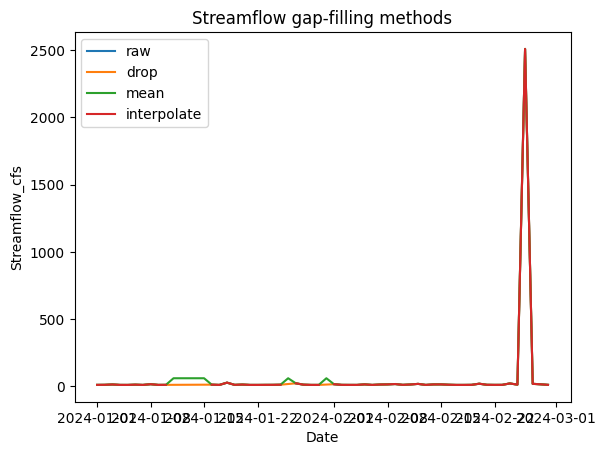

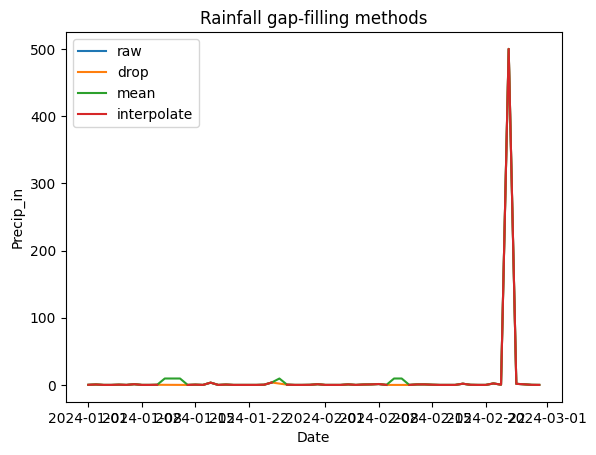

In [42]:
import matplotlib.pyplot as plt

# visualize streamflow methods
def plot_methods(df_dict, column, title):
    fig, ax = plt.subplots()
    for name, df in df_dict.items():
        series = pd.to_numeric(df[column], errors='coerce')  # convert and force NA->nan
        ax.plot(df.index, series, label=name)
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel('Date')
    ax.set_ylabel(column)
    plt.show()

plot_methods(streamflow_methods, 'Streamflow_cfs', 'Streamflow gap‑filling methods')
plot_methods(rainfall_methods, 'Precip_in', 'Rainfall gap‑filling methods')

## Task 7: Combining DataFrames

From the plots above, choose your most representative gap filling dataframe for rainfall and streamflow, and combine them into a rain_flow_df DataFrame.

In [37]:
# choose interpolated series for both variables and merge into one frame
rain_flow_df = pd.DataFrame({
    'Precip_in': rain_interp['Precip_in'],
    'Streamflow_cfs': stream_interp['Streamflow_cfs']
})

rain_flow_df.head()
# display a preview

,Precip_in,Streamflow_cfs
Date,,
2024-01-01,0.14028,10.25
2024-01-02,0.659018,10.7
2024-01-03,0.0,13.3
2024-01-04,0.0,10.1
2024-01-05,0.375729,10.0


## Task 8: Calculate the monthly statistics of the rainfall and discharge

Calculate the monthly total, mean daily (for each month), and the maximum (for each month) rainfall and flow. 

In [36]:
monthly_stream = stream_raw.resample('M').mean()
monthly_rain = rain_raw.resample('M').mean()
monthly_stream.head(), monthly_rain.head()

/scratch/local/u1257442/849844/ipykernel_713953/2372665443.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_stream = stream_raw.resample('M').mean()
/scratch/local/u1257442/849844/ipykernel_713953/2372665443.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rain = rain_raw.resample('M').mean()


(            Streamflow_cfs
 Date                      
 2024-01-31       12.112500
 2024-02-29       99.015517,
            Precip_in
 Date                
 2024-01-31  0.437921
 2024-02-29  18.98449)

## Task 9: Data Corrections

We want to put the data into a streamflow model, but it requires precipitation to be in mm and streamflow to be in CMS (cubic meters per second). Create a new dataframe called rain_flow_SI_df that converts the previous dataframe to SI units.

(The code below assumes `rain_flow_df` was defined in Task 7.)

The conversion factors used are:

* inches → millimetres: ×25.4* cubic feet‑per‑second → cubic metres‑per‑second: ×0.0283168

In [38]:
# convert to SI units using previously merged rain_flow_df
rain_flow_SI_df = rain_flow_df.copy()
rain_flow_SI_df['Precip_mm'] = rain_flow_SI_df['Precip_in'] * 25.4
rain_flow_SI_df['Streamflow_cms'] = rain_flow_SI_df['Streamflow_cfs'] * 0.0283168

# drop original imperial columns if you like
rain_flow_SI_df = rain_flow_SI_df.drop(columns=['Precip_in','Streamflow_cfs'])

rain_flow_SI_df.head()

,Precip_mm,Streamflow_cms
Date,,
2024-01-01,3.56312,0.290247
2024-01-02,16.739058,0.30299
2024-01-03,0.0,0.376613
2024-01-04,0.0,0.286
2024-01-05,9.54352,0.283168


## Task 10: Event diagnostics

A key element of hydroinformatics is to identify key events and learn from them. Here, we have two tasks.
* Create a new column and programatically label each day as 'Dry', 'Light Rain', or 'Heavy Rain' based on the precipitaiton colum.
* From our rain_flow_SI_df, create a new Pandas DataFrame called storm_df that programatically selects the streamflow and precipitation data for 5 days before and after the peak flow event.

In [46]:
columns = ['Dry', 'Light Rain', 'Moderate Rain', 'Heavy Rain']
rain_flow_SI_df['Rain_Category'] = pd.cut(
    rain_flow_SI_df['Precip_mm'],
    bins=[-float('inf'), 0.1, 2.5, 7.6, float('inf')],
    labels=columns
)                                         

TypeError: boolean value of NA is ambiguous

## Task 11: Quick Data Visualziation

Use the pandas plot function to conduct a quick visualization of precipitation and streamflow. Do they seem coorelated? Any glaring errors?